In [ ]:
!pip install torch torchvision pillow matplotlib

In [ ]:
import torch
import torchvision.transforms as transsforms
from PIL import Image
import matplotlib.pyplot as plt



In [ ]:
from google.colab import files
uploaded=files.upload()

Saving pexels-sevenstormphotography-2455398.jpg to pexels-sevenstormphotography-2455398 (1).jpg


In [ ]:
from PIL import Image

content = Image.open("pexels-sevenstormphotography-2455398.jpg")
style = Image.open("Starry Night - Wendy O_ by Hues In Glass, via Flickr.jpg")

(np.float64(-0.5), np.float64(5012.5), np.float64(3760.5), np.float64(-0.5))

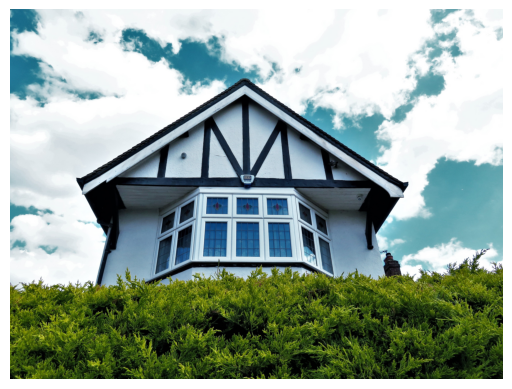

In [ ]:
plt.imshow(content)
plt.axis("off")

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

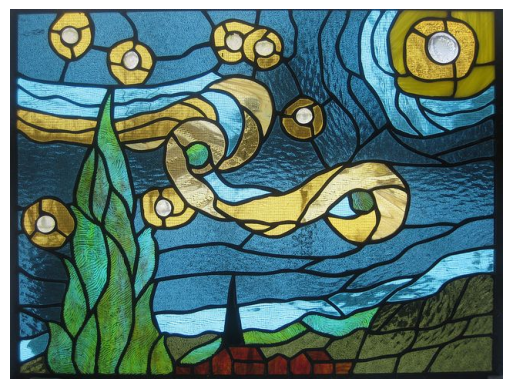

In [ ]:
plt.imshow(style)
plt.axis("off")

In [ ]:
import torchvision.models as models
vgg=models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.eval()

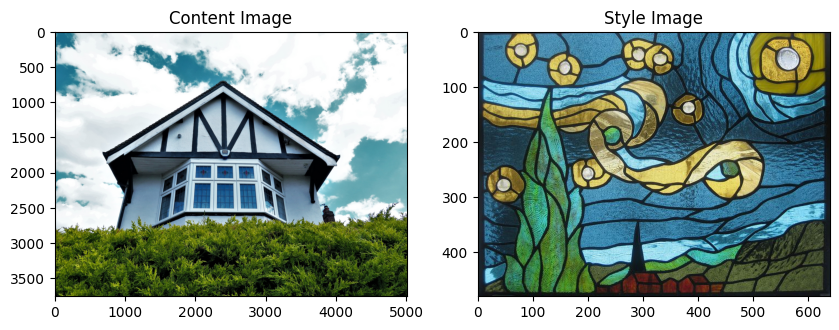

In [ ]:
content = Image.open("pexels-sevenstormphotography-2455398.jpg")
style = Image.open("Starry Night - Wendy O_ by Hues In Glass, via Flickr.jpg")

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(content)
plt.title("Content Image")

plt.subplot(1,2,2)
plt.imshow(style)
plt.title("Style Image")

plt.show()

In [ ]:
import torchvision.transforms as transforms

In [ ]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

content = transform(content).unsqueeze(0)
style = transform(style).unsqueeze(0)

print("Content Shape:", content.shape)
print("Style Shape:", style.shape)

Content Shape: torch.Size([1, 3, 256, 256])
Style Shape: torch.Size([1, 3, 256, 256])


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

content = content.to(device)
style = style.to(device)

generated = content.clone().requires_grad_(True)

print("Device:", device)

Device: cuda


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

content = content.to(device)
style = style.to(device)

generated = content.clone().requires_grad_(True).to(device)

optimizer = optim.Adam([generated], lr=0.01)

print("Setup Completed")

Setup Completed


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vgg = vgg.to(device)

content = content.to(device)
style = style.to(device)
generated = generated.to(device)

In [ ]:
def gram_matrix(input):
    batch_size, channels, height, width = input.size()
    features = input.view(batch_size * channels, height * width)
    gram = torch.mm(features, features.t())
    return gram.div(batch_size * channels * height * width)

content_features = vgg(content)
style_features = vgg(style)
generated_features = vgg(generated)

content_loss = torch.mean((generated_features - content_features) ** 2)

style_loss = torch.mean(
    (gram_matrix(generated_features) - gram_matrix(style_features)) ** 2
)

print("Content Loss:", content_loss.item())
print("Style Loss:", style_loss.item())

Content Loss: 0.0
Style Loss: 7.647098243523942e-08


In [ ]:
import torch.optim as optim

optimizer = optim.Adam([generated], lr=0.01)

print("Optimizer created successfully")

Optimizer created successfully


In [ ]:
with torch.no_grad():
    content_features = vgg(content)
    style_features = vgg(style)

alpha = 1
beta = 10000000

for step in range(5000):

    optimizer.zero_grad()

    generated_features = vgg(generated)

    content_loss = torch.mean((generated_features - content_features) ** 2)

    style_loss = torch.mean(
        (gram_matrix(generated_features) - gram_matrix(style_features)) ** 2
    )

    total_loss = alpha * content_loss + beta * style_loss

    total_loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print(f"Step {step}, Loss: {total_loss.item()}")

Step 0, Loss: 0.20305649936199188
Step 50, Loss: 0.2037031054496765
Step 100, Loss: 0.20286566019058228
Step 150, Loss: 0.2028576284646988
Step 200, Loss: 0.2026645839214325
Step 250, Loss: 0.20264218747615814
Step 300, Loss: 0.20265540480613708
Step 350, Loss: 0.20254641771316528
Step 400, Loss: 0.20294071733951569
Step 450, Loss: 0.20247167348861694
Step 500, Loss: 0.20241037011146545
Step 550, Loss: 0.20257748663425446
Step 600, Loss: 0.20271645486354828
Step 650, Loss: 0.20252525806427002
Step 700, Loss: 0.20305632054805756
Step 750, Loss: 0.20235976576805115
Step 800, Loss: 0.2022842913866043
Step 850, Loss: 0.2023841291666031
Step 900, Loss: 0.20250603556632996
Step 950, Loss: 0.20242831110954285
Step 1000, Loss: 0.20225180685520172
Step 1050, Loss: 0.20235052704811096
Step 1100, Loss: 0.20240990817546844
Step 1150, Loss: 0.20213982462882996
Step 1200, Loss: 0.20197464525699615
Step 1250, Loss: 0.20248472690582275
Step 1300, Loss: 0.20201189815998077
Step 1350, Loss: 0.2030245661

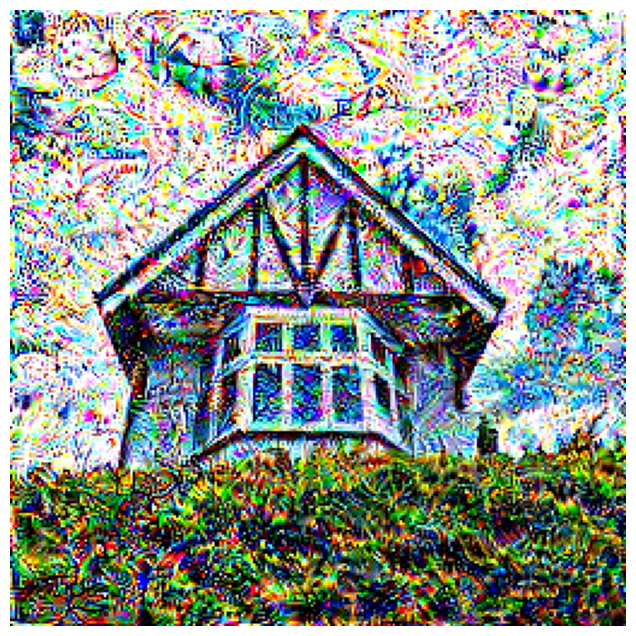

In [ ]:
output = generated.detach().cpu().squeeze(0)
output = output.permute(1, 2, 0).numpy()
output = output.clip(0, 1)

plt.figure(figsize=(8,8))
plt.imshow(output)
plt.axis("off")
plt.show()

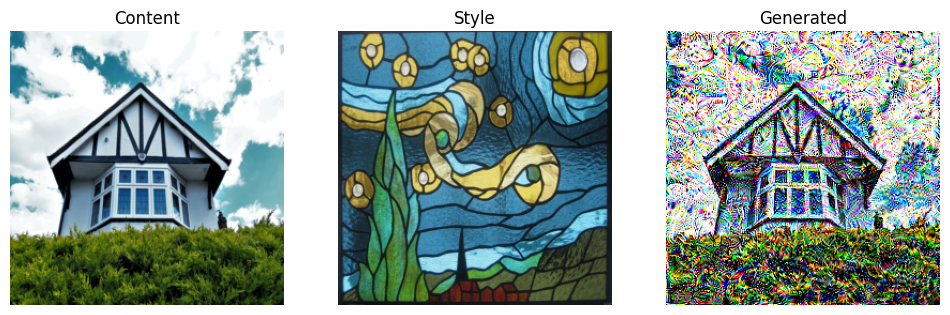

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(content.squeeze().permute(1,2,0).cpu())
plt.title("Content")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(style.squeeze().permute(1,2,0).cpu())
plt.title("Style")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(output)
plt.title("Generated")
plt.axis("off")

plt.show()